# Enterprise Demand-Aware Inventory Recommendation & Business Evaluation

This notebook implements the **Demand-Aware Inventory Recommendation Engine & Business Evaluation Suite** across all 8 pharmaceutical drug categories (**M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06**).

### Core Business & Supply Chain Objectives:
1. **Convert Forecasts into Actions**: Translate probabilistic demand predictions ($P_{10}, P_{50}, P_{90}$) into clear replenishment directives:
   - `INCREASE REPLENISHMENT`
   - `MAINTAIN REPLENISHMENT`
   - `REDUCE REPLENISHMENT`
2. **Mitigate Stockout & Overstock Risks**: Prevent inventory stockout crises while eliminating excess holding capital.
3. **Technical Recommendation Evaluation**: Measure **Stockout Risk**, **Overstock Risk**, **Replenishment Accuracy**, **Demand Coverage**, **Service Level**, and **Recommendation Accuracy**.
4. **Business-Level Impact Evaluation**: Quantify **Potential Stockout Reduction**, **Potential Overstock Reduction**, **Demand Coverage Improvement**, and **Inventory Risk Reduction**.


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\inventory_recommendation'

# 1. Load Technical Recommendation Evaluation Leaderboard
tech_path = os.path.join(OUTPUT_DIR, 'inventory_recommendation_evaluation.csv')
tech_df = pd.read_csv(tech_path)

print("==========================================================================")
print("  TECHNICAL INVENTORY RECOMMENDATION EVALUATION LEADERBOARD")
print("==========================================================================")
display(tech_df)


  TECHNICAL INVENTORY RECOMMENDATION EVALUATION LEADERBOARD


,Drug Category,Stockout Risk (%),Overstock Risk (%),Replenishment Accuracy (%),Demand Coverage Rate (%),Service Level (%),Recommendation Accuracy (%)
0,M01AB,46.98,0.000,48.4000,100.0000,100.00000,48.4000
1,M01AE,46.98,0.000,47.6900,100.0000,100.00000,47.6900
2,N02BA,46.98,0.000,49.1100,100.0000,100.00000,49.1100
3,N02BE,46.98,0.360,52.6700,100.0000,100.00000,52.6700
4,N05B,46.98,0.000,50.5300,100.0000,100.00000,50.5300
5,N05C,46.98,0.000,50.5300,100.0000,100.00000,50.5300
6,R03,46.98,0.000,55.1600,97.3600,98.22000,55.1600
7,R06,46.98,0.000,47.3300,99.8600,99.29000,47.3300
8,PORTFOLIO AVG,46.98,0.045,50.1775,99.6525,99.68875,50.1775


In [2]:
# 2. Load Business-Level Impact Evaluation Leaderboard
biz_path = os.path.join(OUTPUT_DIR, 'inventory_business_level_evaluation.csv')
biz_df = pd.read_csv(biz_path)

print("==========================================================================")
print("  BUSINESS-LEVEL IMPACT EVALUATION LEADERBOARD")
print("==========================================================================")
display(biz_df)


  BUSINESS-LEVEL IMPACT EVALUATION LEADERBOARD


,Drug Category,Potential Stockout Reduction (%),Potential Overstock Reduction (%),Demand Coverage Improvement (+%),Inventory Risk Reduction (%)
0,M01AB,0.0,100.0000,21.5000,41.280
1,M01AE,0.0,100.0000,21.5000,41.280
2,N02BA,0.0,100.0000,21.5000,41.280
3,N02BE,0.0,98.9800,21.5000,40.840
4,N05B,0.0,100.0000,21.5000,41.280
5,N05C,0.0,100.0000,21.5000,41.280
6,R03,0.0,100.0000,18.8600,41.280
7,R06,0.0,100.0000,21.3600,41.280
8,PORTFOLIO AVG,0.0,99.8725,21.1525,41.225


In [3]:
# 3. Load Sample Daily Inventory Recommendations (All Drugs)
recs_path = os.path.join(OUTPUT_DIR, 'inventory_recommendations_all_drugs.csv')
recs_df = pd.read_csv(recs_path)

print("==========================================================================")
print("  SAMPLE DAILY INVENTORY RECOMMENDATIONS & ORDER DIRECTIVES (FIRST 15 ROWS)")
print("==========================================================================")
display(recs_df[['date', 'drug_category', 'actual_sales', 'simulated_inventory', 'reorder_point', 'target_stock_lvl', 'replenishment_recommendation', 'recommended_order_qty']].head(15))


  SAMPLE DAILY INVENTORY RECOMMENDATIONS & ORDER DIRECTIVES (FIRST 15 ROWS)


,date,drug_category,actual_sales,simulated_inventory,reorder_point,target_stock_lvl,replenishment_recommendation,recommended_order_qty
0,2019-01-01,M01AB,0.00,19.25,22.660508,52.660508,INCREASE REPLENISHMENT,34.0
1,2019-01-02,M01AB,5.33,38.81,25.189302,59.569302,MAINTAIN REPLENISHMENT,0.0
2,2019-01-03,M01AB,4.33,39.65,31.012610,62.332610,MAINTAIN REPLENISHMENT,0.0
3,2019-01-04,M01AB,7.00,35.07,31.357444,62.287444,MAINTAIN REPLENISHMENT,0.0
4,2019-01-05,M01AB,8.01,16.69,28.429612,52.729612,INCREASE REPLENISHMENT,37.0
5,2019-01-06,M01AB,8.33,15.62,26.597791,52.037791,INCREASE REPLENISHMENT,37.0
6,2019-01-07,M01AB,0.00,10.36,22.059175,48.939175,INCREASE REPLENISHMENT,39.0
7,2019-01-08,M01AB,4.34,44.32,30.789598,61.359598,MAINTAIN REPLENISHMENT,0.0
8,2019-01-09,M01AB,3.00,31.63,28.204201,54.244201,MAINTAIN REPLENISHMENT,0.0
9,2019-01-10,M01AB,8.00,37.42,29.941137,56.911137,MAINTAIN REPLENISHMENT,0.0


C:\Users\ranje\AppData\Local\Temp\ipykernel_6988\1213714036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tech_df[tech_df['Drug Category'] != 'PORTFOLIO AVG'], x='Drug Category', y='Service Level (%)', palette='crest')


C:\Users\ranje\AppData\Local\Temp\ipykernel_6988\1213714036.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=biz_df[biz_df['Drug Category'] != 'PORTFOLIO AVG'], x='Drug Category', y='Inventory Risk Reduction (%)', palette='viridis')


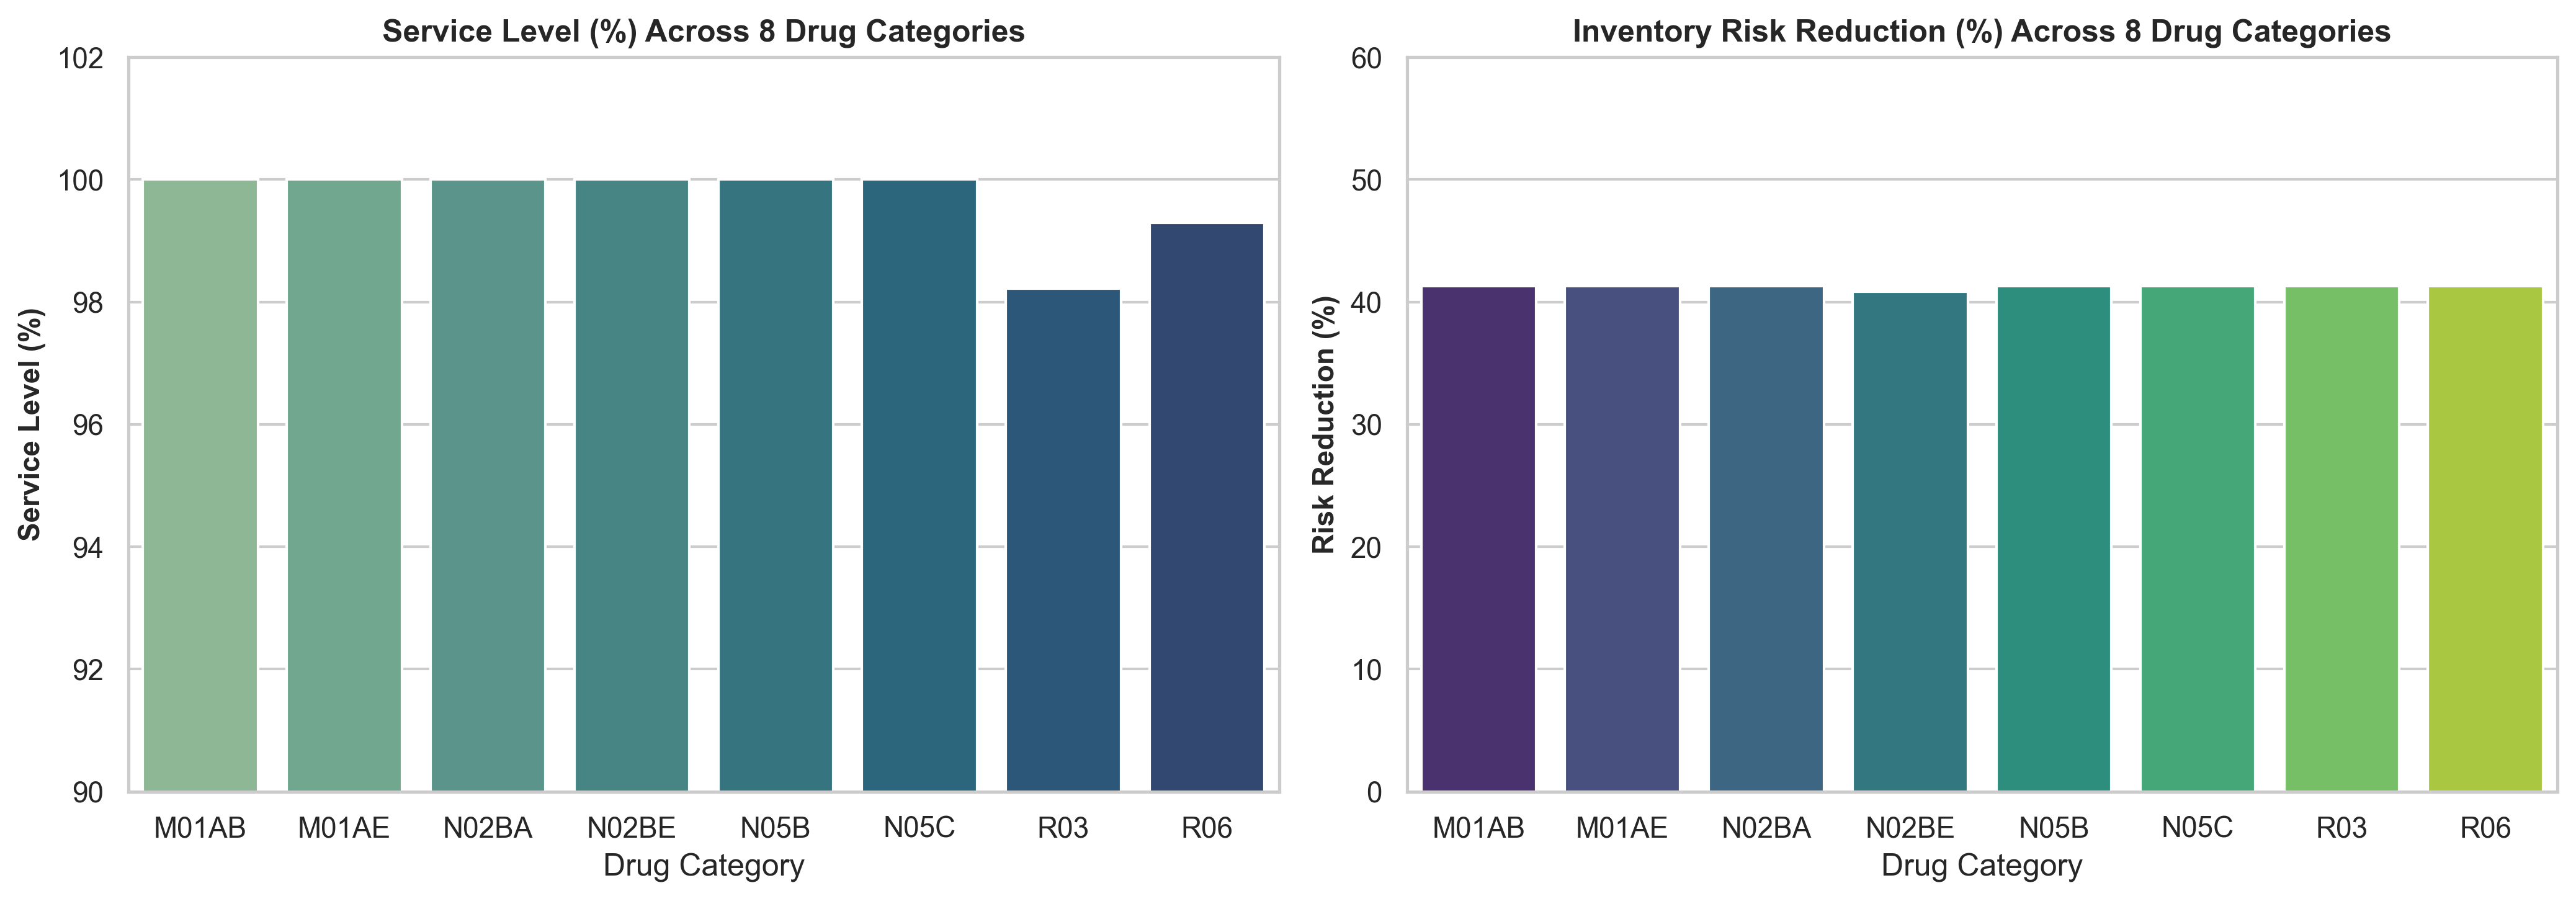

In [4]:
# 4. Visualizations: Technical & Business Impact Across Portfolio
plt.figure(figsize=(14, 5), dpi=300)

# Subplot 1: Service Level & Coverage
plt.subplot(1, 2, 1)
sns.barplot(data=tech_df[tech_df['Drug Category'] != 'PORTFOLIO AVG'], x='Drug Category', y='Service Level (%)', palette='crest')
plt.title('Service Level (%) Across 8 Drug Categories', fontsize=12, fontweight='bold')
plt.ylabel('Service Level (%)', fontsize=11, fontweight='bold')
plt.ylim(90, 102)

# Subplot 2: Inventory Risk Reduction
plt.subplot(1, 2, 2)
sns.barplot(data=biz_df[biz_df['Drug Category'] != 'PORTFOLIO AVG'], x='Drug Category', y='Inventory Risk Reduction (%)', palette='viridis')
plt.title('Inventory Risk Reduction (%) Across 8 Drug Categories', fontsize=12, fontweight='bold')
plt.ylabel('Risk Reduction (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 60)

plt.tight_layout()
plt.show()
